In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [2]:
import joblib
data = joblib.load('saved_vars.pkl')
globals().update(data)


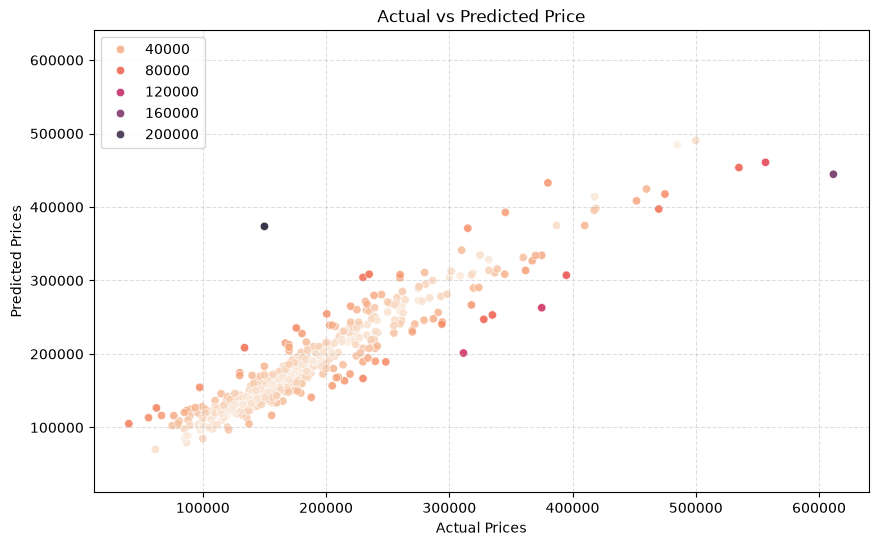

In [ ]:
residuals = abs(y_test - y_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, hue=residuals, palette='rocket_r', alpha=0.8)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red', alpha=0.0)
plt.title('Actual vs Predicted Price with Residuals')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(linestyle='--', alpha=0.4)
plt.show()

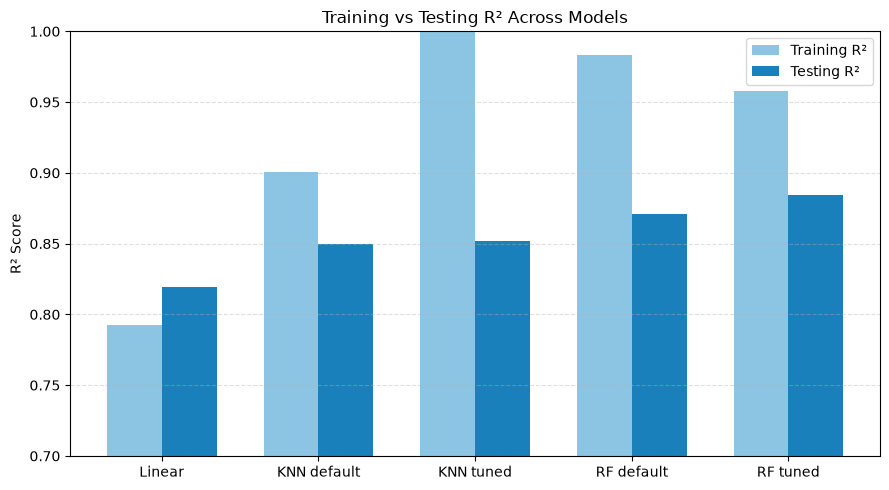

In [4]:
models = ['Linear', 'KNN default', 'KNN tuned', 'RF default', 'RF tuned']
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_r2, width=width, label='Training R²', color='#8cc5e3')
ax.bar(x + width/2, test_r2, width=width, label='Testing R²', color='#1a80bb')
ax.set_title('Training vs Testing R² Across Models')
ax.set_ylabel('R² Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.70, 1.00)
plt.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

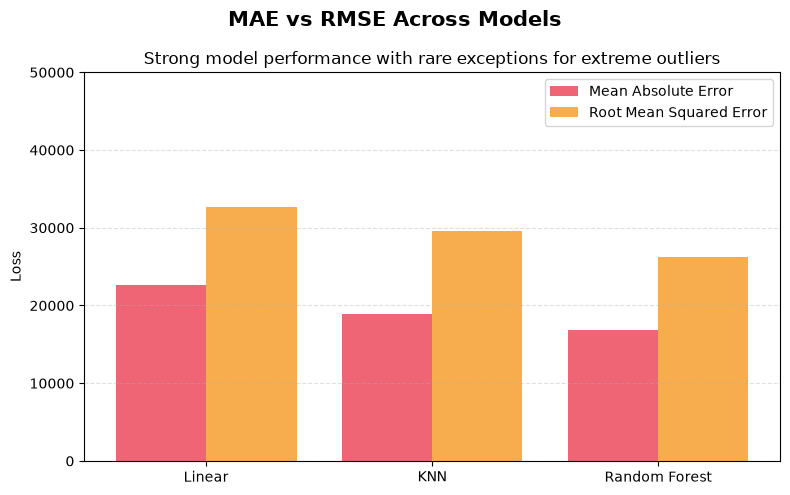

In [5]:
models = ['Linear', 'KNN', 'Random Forest']
x = np.arange(len(models))
width = 0.4

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('MAE vs RMSE Across Models', fontsize=15, fontweight='bold')
ax.bar(x - width/2, maes, width=width, label='Mean Absolute Error', color='#f06575')
ax.bar(x + width/2, rmses, width=width, label='Root Mean Squared Error', color='#f7ad4d')
ax.set_title('Strong model performance with rare exceptions for extreme outliers')
ax.set_ylabel('Loss')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 50000)
plt.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



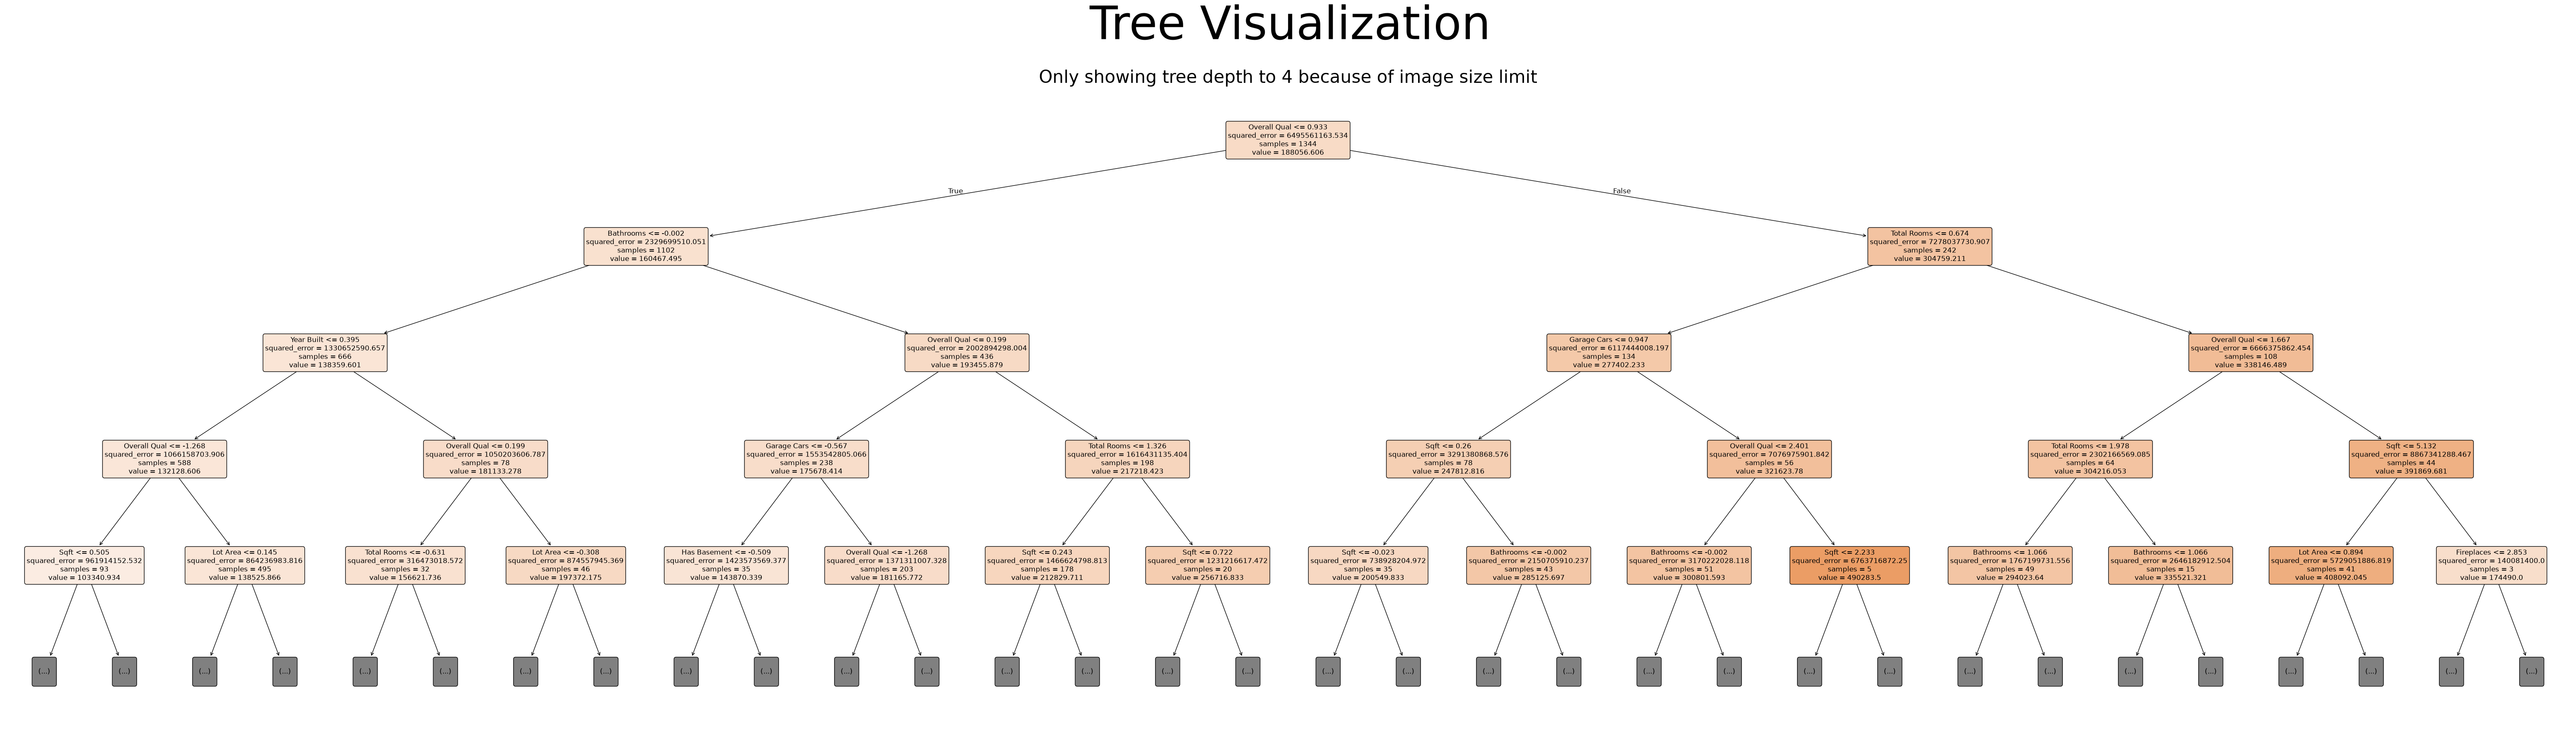

In [6]:
tree = rf_regressor_tuned.estimators_[0]
plt.figure(figsize=(80, 20))
plot_tree(tree,
          max_depth=4,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=12)
plt.suptitle('      Tree Visualization', fontsize=80)
plt.title('Only showing tree depth to 4 because of image size limit', fontsize=30)
plt.show()

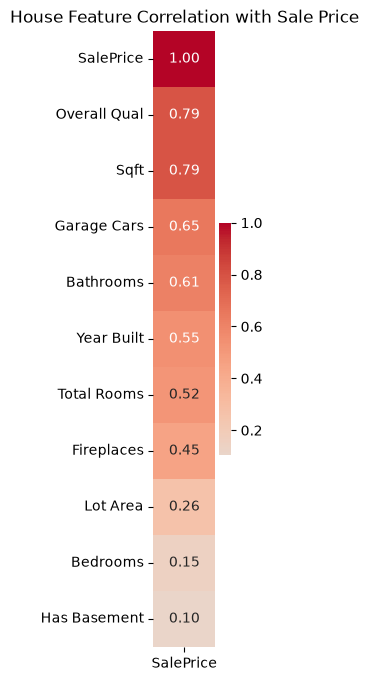

In [7]:
sale_price_corr = df.corr()[['SalePrice']]
sale_price_corr = sale_price_corr.sort_values(by='SalePrice', ascending=False)
plt.figure(figsize=(1, 8))
sns.heatmap(sale_price_corr, annot=True, fmt='.2f', center=0.0, cmap='coolwarm')
plt.title('House Feature Correlation with Sale Price')
plt.show()